# Self-Organizing Maps — Basics
A hands-on introduction to SOMs using the Iris dataset.
We'll train a SOM, visualize the U-Matrix, hit map, and component planes.

In [2]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from kohonen.som import SOM

In [3]:
iris = load_iris()
X = iris.data
y = iris.target
labels = [iris.target_names[i] for i in y]

print(f"Dataset shape: {X.shape}")
print(f"Features: {iris.feature_names}")
print(f"Classes: {iris.target_names}")

Dataset shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


## Choosing Grid Size
Rule of thumb: total neurons ≈ 5 × √(n_samples)

In [4]:
som = SOM(grid_x=10, grid_y=10)
som.suggest_grid_size(len(X))

Suggested grid size for 150 samples: 8x8 (64 neurons)


(8, 8)

## Train

In [6]:
som = SOM(grid_x=8, grid_y=8, learning_rate=0.5, sigma=1.5)
som.fit(X, epochs=1000)

Training SOM (8x8) for 1000 epochs...
Done. Quantization Error: 0.0683 | Topographic Error: 0.0467


## U-Matrix
Dark regions = cluster boundaries. Light regions = cluster centers.

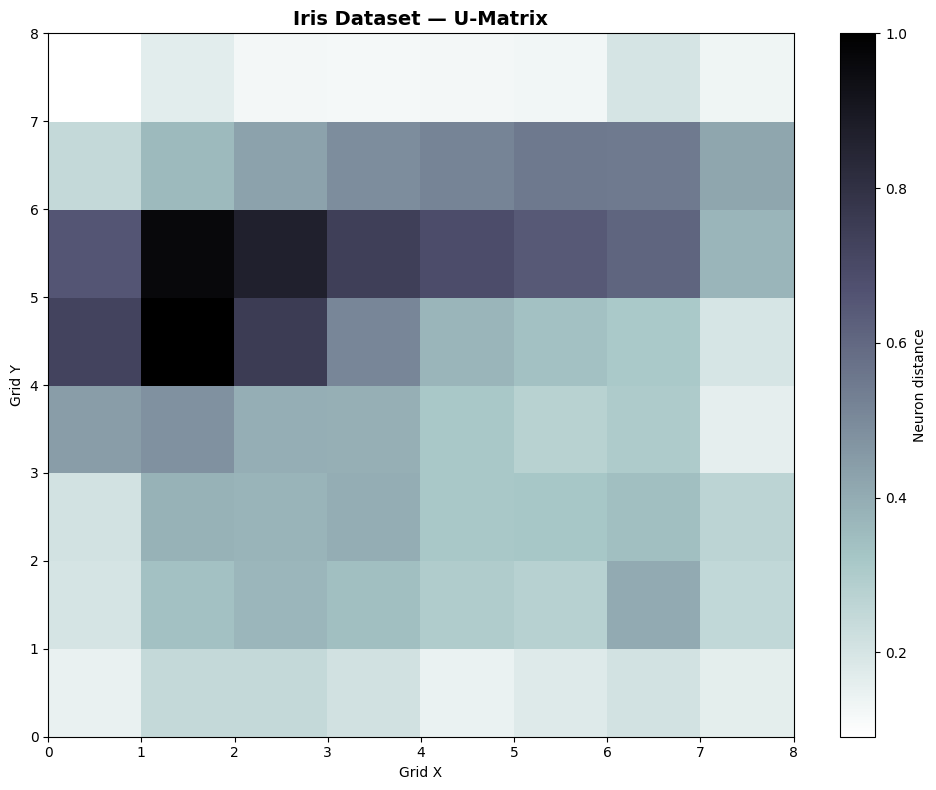

In [7]:
som.plot_umatrix(title="Iris Dataset — U-Matrix")

## Hit Map
Shows where each class lands on the map.
Well-separated color clusters = good topology preservation.

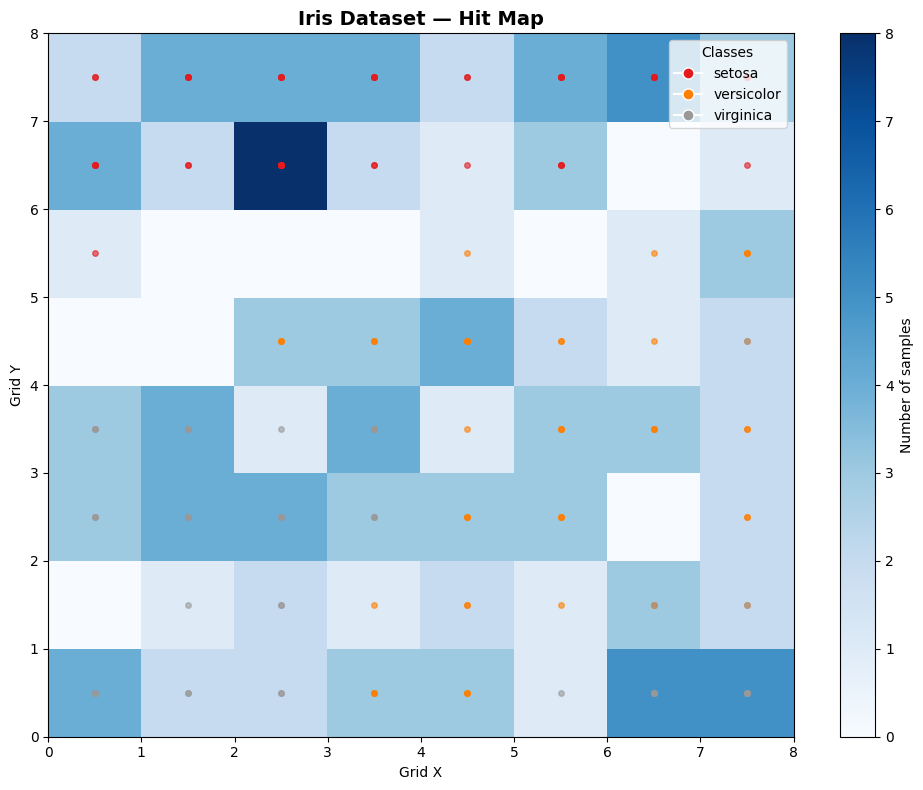

In [8]:
som.plot_heatmap(X, labels=labels, title="Iris Dataset — Hit Map")

## Component Planes
How each feature varies across the map.
Helps understand which features drive the clustering.

In [9]:
print(f"Quantization Error : {som.quantization_error():.4f}")
print(f"Topographic Error  : {som.topographic_error():.4f}")

Quantization Error : 0.0683
Topographic Error  : 0.0467
